# N1 · Geo-Experiment Design for a Branch Network

**Panel question** — asked by the **Head of Data** (geo-lift / location
demand forecasting is his specialism): *"You want to test a margin change
across the branch estate. Design it."*

Four things a senior answer must contain, all computed here:
1. **Interference** — cross-shopping between nearby branches makes
   branch-level randomisation lie about *network* incrementality; online
   visibility contaminates controls and attenuates the estimate.
2. **The fix** — cluster-randomise at travel-to-work-area (TTWA) level with
   buffer zones, and report *minimum lift under leakage* when contamination
   is unavoidable.
3. **Power** — the honest MDE at realistic estate sizes; CUPED to buy it down.
4. **Synthetic control** — the observational fallback when you can't randomise.

**Contract:** known truth (+2.0% branch lift) → naive designs mis-measure it
→ correct design recovers it.

In [1]:
# %matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.vq import kmeans2
from scipy.optimize import minimize
from scipy.spatial.distance import cdist

from _style import C, apply_style
apply_style()
rng = np.random.default_rng(11)

# --- The estate: 400 branches on a map, with size and a stable weekly level --
N = 400
xy = rng.uniform(0, 100, (N, 2))
size = rng.lognormal(np.log(40_000), 0.6, N)         # weekly £ revenue level
TRUE_LIFT = 0.02                                     # the margin change ADDS 2%
NOISE = 0.045                                        # branch-week noise (cv)

D = cdist(xy, xy)                                    # branch-to-branch distances

def week_revenue(base, lift=None, rng=rng):
    l = np.zeros(N) if lift is None else lift
    return base * (1 + l) * rng.lognormal(0, NOISE, N)

print(f"{N} branches | true branch-level lift when treated: +{TRUE_LIFT:.0%}")

400 branches | true branch-level lift when treated: +2%


## 1a. Interference I — cross-shopping (the reallocation problem)

The tested change is a better rate. Customers near a treated branch divert
purchases *away from nearby control branches*. Treated revenue rises by the
genuine lift **plus stolen volume**; controls fall. Branch-level
treated-vs-control then **overstates network incrementality** — you'd approve
a margin giveaway that partly just moves money between your own tills.

In [2]:
def run_branch_randomised(phi=0.02, lam=3.0, seed=0):
    """One 4-week test with branch-level randomisation + cross-shopping.
    phi = max diverted share; lam = distance scale of cross-shopping (map units)."""
    r = np.random.default_rng(seed)
    treat = r.random(N) < 0.5
    kern = np.exp(-D / lam) * (~np.eye(N, dtype=bool))
    # control branch b loses volume toward nearby treated branches
    pull = kern[:, treat].sum(axis=1)
    divert_share = np.where(~treat, phi * pull / (1 + pull), 0.0)

    est, net = [], []
    for wk in range(4):
        base = week_revenue(size, rng=r)                       # no-test world
        lift = np.where(treat, TRUE_LIFT, 0.0)
        rev = week_revenue(size, lift, rng=r)
        stolen = rev * divert_share                            # leaves controls
        rev = rev - stolen
        # stolen volume lands on nearby treated branches
        w = kern[np.ix_(~treat, treat)]
        w = np.where(w > 0.05, w, 0.0)                         # only lands NEARBY
        ws = w.sum(axis=1, keepdims=True)
        frac = np.divide(w, ws, out=np.zeros_like(w), where=ws > 0)
        rev[treat] += (stolen[~treat][:, None] * frac).sum(axis=0)
        est.append(rev[treat].sum() / base[treat].sum()
                   - rev[~treat].sum() / base[~treat].sum())
        net.append(rev.sum() / base.sum())
    return np.mean(est), np.mean(net) - 1  # measured lift, true network lift

measured, network = np.mean([run_branch_randomised(seed=s) for s in range(60)], axis=0)
print(f"True branch-level lift        : +{TRUE_LIFT:.2%}")
print(f"True NETWORK incrementality   : +{network:.2%}   (half the estate treated)")
print(f"Branch-randomised estimate    : +{measured:.2%}   "
      f"<- overstates the causal lift by {(measured - TRUE_LIFT)/TRUE_LIFT:+.0%}")
print("Cross-shopping is zero-sum for the network but NOT for the contrast: "
      "treated gain what controls lose.")

True branch-level lift        : +2.00%
True NETWORK incrementality   : +1.02%   (half the estate treated)
Branch-randomised estimate    : +3.94%   <- overstates the causal lift by +97%
Cross-shopping is zero-sum for the network but NOT for the contrast: treated gain what controls lose.


## 1b. Interference II — online visibility (the attenuation problem)

If the tested rate is visible online (comparison sites, click-&-collect),
control-branch customers are **partially treated**: the contrast shrinks.
Direction matters and depends on the channel — reallocation *inflates*,
partial treatment *attenuates*. Quantify the attenuation and report the
**minimum lift under leakage**.

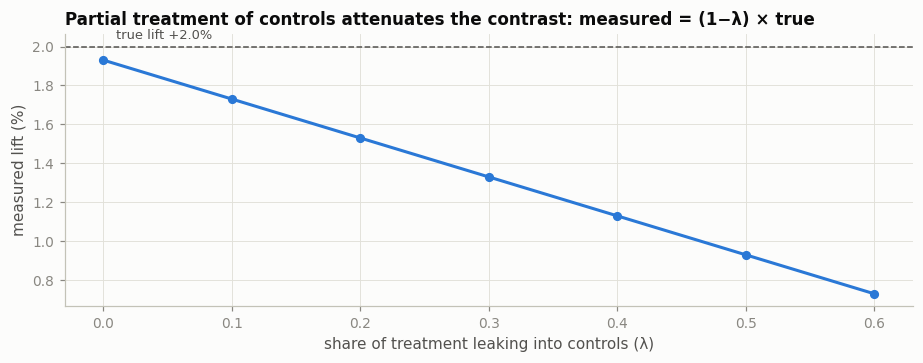

If contamination is unknown but bounded at λ ≤ 30%: measured +1.33% is the MINIMUM lift; true lies in [+1.33%, +1.90%].


In [3]:
lams = np.linspace(0, 0.6, 7)
rows = []
for contam in lams:
    ests = []
    for s in range(40):
        r = np.random.default_rng(100 + s)
        treat = r.random(N) < 0.5
        lift = np.where(treat, TRUE_LIFT, contam * TRUE_LIFT)   # controls part-treated
        base = week_revenue(size, rng=r)
        rev = week_revenue(size, lift, rng=r)
        ests.append(rev[treat].sum() / base[treat].sum()
                    - rev[~treat].sum() / base[~treat].sum())
    rows.append((contam, np.mean(ests)))
att = pd.DataFrame(rows, columns=["contamination", "measured_lift"])

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.plot(att.contamination, att.measured_lift * 100, color=C["blue"], marker="o", ms=5)
ax.axhline(TRUE_LIFT * 100, color=C["ink2"], ls="--", lw=1)
ax.text(0.01, TRUE_LIFT * 100 + 0.04, "true lift +2.0%", fontsize=8.5, color=C["ink2"])
ax.set_xlabel("share of treatment leaking into controls (λ)")
ax.set_ylabel("measured lift (%)")
ax.set_title("Partial treatment of controls attenuates the contrast: measured = (1−λ) × true")
plt.tight_layout(); plt.show()

lam_max = 0.3
m = att.loc[np.isclose(att.contamination, lam_max), "measured_lift"].iloc[0]
print(f"If contamination is unknown but bounded at λ ≤ {lam_max:.0%}: "
      f"measured +{m:.2%} is the MINIMUM lift; true lies in "
      f"[+{m:.2%}, +{m/(1-lam_max):.2%}].")

## 2. The fix — cluster at TTWA level, with buffer zones

Randomise **travel-to-work areas**, not branches: cross-shopping is contained
*within* a cluster, so it nets out inside each arm. Exclude boundary branches
(within buffer distance of the other arm) from measurement.

In [4]:
K = 40
_, cluster = kmeans2(xy, K, seed=3, minit="++")

def run_cluster_randomised(phi=0.02, lam=3.0, buffer=10.0, seed=0):
    r = np.random.default_rng(seed)
    c_treat = r.random(K) < 0.5
    treat = c_treat[cluster]
    kern = np.exp(-D / lam) * (~np.eye(N, dtype=bool))
    pull = kern[:, treat].sum(axis=1)
    divert = np.where(~treat, phi * pull / (1 + pull), 0.0)

    # buffer: drop branches too close to any opposite-arm branch
    d_opp = np.where(treat[:, None] != treat[None, :], D, np.inf).min(axis=1)
    keep = d_opp > buffer

    est = []
    for wk in range(4):
        base = week_revenue(size, rng=r)
        rev = week_revenue(size, np.where(treat, TRUE_LIFT, 0.0), rng=r)
        stolen = rev * divert
        rev = rev - stolen
        w = kern[np.ix_(~treat, treat)]
        w = np.where(w > 0.05, w, 0.0)                         # only lands NEARBY
        ws = w.sum(axis=1, keepdims=True)
        frac = np.divide(w, ws, out=np.zeros_like(w), where=ws > 0)
        rev[treat] += (stolen[~treat][:, None] * frac).sum(axis=0)
        est.append(rev[treat & keep].sum() / base[treat & keep].sum()
                   - rev[~treat & keep].sum() / base[~treat & keep].sum())
    return np.mean(est), keep.mean()

ests = [run_cluster_randomised(seed=s) for s in range(60)]
cl_est = np.mean([e for e, _ in ests])
kept = np.mean([k for _, k in ests])
print(f"Cluster-randomised (TTWA) + buffer estimate: +{cl_est:.2%}  "
      f"(true +{TRUE_LIFT:.0%}; branch-level design said +{measured:.2%})")
print(f"Buffer keeps {kept:.0%} of branches in the measurement set — "
      "you PAY data for identification, and that trade is worth stating out loud.")

# The buffer-width sweep IS the design decision: bias falls, data melts.
print("\nBuffer-width sensitivity (show this to the review, not just one number):")
for buf in (6, 8, 10, 12):
    res = [run_cluster_randomised(buffer=buf, seed=s) for s in range(60)]
    e, k = np.mean([x for x, _ in res]), np.mean([x for _, x in res])
    print(f"  buffer {buf:>2}: estimate +{e:.2%}, branches kept {k:.0%}")
print("Residual boundary leakage never fully dies — quote the estimate as an "
      "UPPER bound alongside the buffer sweep, not as a point fact.")

Cluster-randomised (TTWA) + buffer estimate: +2.05%  (true +2%; branch-level design said +3.94%)
Buffer keeps 40% of branches in the measurement set — you PAY data for identification, and that trade is worth stating out loud.

Buffer-width sensitivity (show this to the review, not just one number):


  buffer  6: estimate +2.37%, branches kept 80%


  buffer  8: estimate +2.17%, branches kept 59%


  buffer 10: estimate +2.05%, branches kept 40%


  buffer 12: estimate +1.94%, branches kept 27%
Residual boundary leakage never fully dies — quote the estimate as an UPPER bound alongside the buffer sweep, not as a point fact.


## 3. Power — the MDE nobody wants to hear

Simulate the estimator's null distribution at three estate sizes and convert
to the minimum detectable effect (80% power, two-sided 5%). Then translate
margin moves into expected revenue effects: at a pocket spread of ~430bps and
channel elasticity ε ≈ −1.3, a margin cut of Δbps lifts volume by roughly
`|ε| × Δ/430`.

In [5]:
def mde(n_branches, weeks=4, reps=1500, seed=5):
    r = np.random.default_rng(seed)
    s = rng.choice(size, n_branches, replace=False)
    nulls = []
    for _ in range(reps):
        tr = r.random(n_branches) < 0.5
        diffs = []
        for _ in range(weeks):
            base = s * r.lognormal(0, NOISE, n_branches)
            diffs.append(base[tr].sum() / s[tr].sum() - base[~tr].sum() / s[~tr].sum())
        nulls.append(np.mean(diffs))
    return 2.8 * np.std(nulls)          # (z_{0.975}+z_{0.8}) x SE

sizes_n = [50, 100, 400]
mdes = {n: mde(n) for n in sizes_n}
moves = pd.DataFrame({"margin_move_bps": [5, 10, 25]})
moves["expected_revenue_effect"] = 1.3 * moves.margin_move_bps / 430

print("MDE by estate size (4-week test):")
for n, v in mdes.items():
    print(f"  {n:>4} branches: MDE = {v:.2%}")
print("\nExpected effect of margin moves (ε=-1.3, pocket 430bps):")
for _, row in moves.iterrows():
    detectable = {n: "yes" if row.expected_revenue_effect > v else "NO"
                  for n, v in mdes.items()}
    print(f"  {row.margin_move_bps:>4.0f}bps -> +{row.expected_revenue_effect:.2%}  "
          f"detectable at 50/100/400: {detectable[50]}/{detectable[100]}/{detectable[400]}")

MDE by estate size (4-week test):
    50 branches: MDE = 2.05%
   100 branches: MDE = 1.57%
   400 branches: MDE = 0.77%

Expected effect of margin moves (ε=-1.3, pocket 430bps):
     5bps -> +1.51%  detectable at 50/100/400: NO/NO/yes
    10bps -> +3.02%  detectable at 50/100/400: yes/yes/yes
    25bps -> +7.56%  detectable at 50/100/400: yes/yes/yes


Read the table honestly: a **5bps margin move is invisible to a 50–100 branch
pilot** — only the full estate can see it, and anything smaller than that
needs a longer window or a Bayesian decision readout (see N4). Note the
convention: elasticity here is to the **FX margin itself** (the repo's
`log_fee` convention), which is why small bps moves still produce visible
volume effects. Then buy power with **CUPED**.

In [6]:
def mde_cuped(n_branches, rho=0.85, weeks=4, reps=1500, seed=6):
    """Pre-period revenue as the CUPED covariate with correlation rho."""
    r = np.random.default_rng(seed)
    s = rng.choice(size, n_branches, replace=False)
    nulls = []
    for _ in range(reps):
        tr = r.random(n_branches) < 0.5
        diffs = []
        for _ in range(weeks):
            shock = r.normal(0, NOISE, n_branches)
            y = shock                                  # branch % deviation
            x = rho * shock + np.sqrt(1 - rho**2) * r.normal(0, NOISE, n_branches)
            theta = np.cov(y, x)[0, 1] / x.var()
            y_adj = y - theta * (x - x.mean())
            diffs.append(y_adj[tr].mean() - y_adj[~tr].mean())
        nulls.append(np.mean(diffs))
    return 2.8 * np.std(nulls)

for n in sizes_n:
    raw, adj = mdes[n], mde_cuped(n)
    print(f"  {n:>4} branches: MDE {raw:.2%} -> {adj:.2%} with CUPED "
          f"({1 - adj/raw:.0%} smaller)")
print("\nCUPED variance reduction ~ (1 - rho^2): a strong pre-period covariate "
      "is the cheapest power you will ever buy.")

    50 branches: MDE 2.05% -> 0.92% with CUPED (55% smaller)


   100 branches: MDE 1.57% -> 0.67% with CUPED (58% smaller)


   400 branches: MDE 0.77% -> 0.33% with CUPED (57% smaller)

CUPED variance reduction ~ (1 - rho^2): a strong pre-period covariate is the cheapest power you will ever buy.


## 4. Synthetic control — when you can't randomise

A competitor opens next to 50 branches in week 9 of 20 (–6% revenue). You
can't randomise that. Build a synthetic control for the affected group from
the 350 unaffected donors and read the effect off the gap.

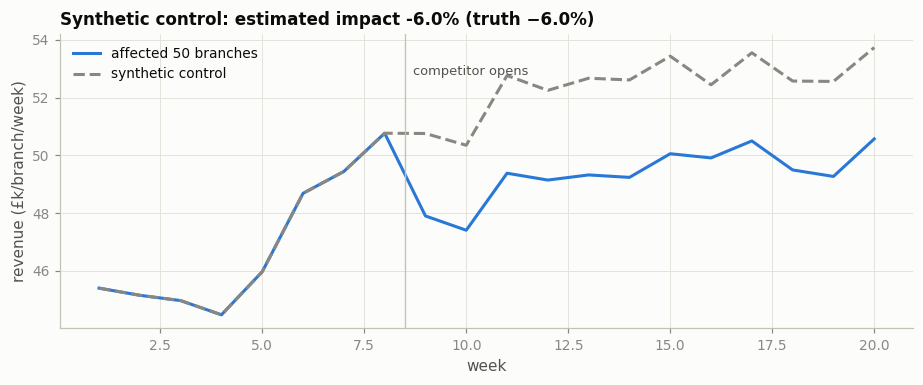

Estimated competitor impact: -5.96%  (known truth: -6.00%)


In [7]:
T_W, EVENT = 20, 8
common = rng.normal(0, 0.02, T_W).cumsum()             # shared market drift
affected = rng.choice(N, 50, replace=False)
mask_aff = np.zeros(N, bool); mask_aff[affected] = True

path = np.empty((N, T_W))
for t in range(T_W):
    hit = mask_aff & (t >= EVENT)
    path[:, t] = size * (1 + common[t]) * (1 - 0.06 * hit) \
        * rng.lognormal(0, 0.02, N)

# Work per-branch (mean) so treated and donors live on the same scale, and
# subsample the donor pool — classic SC wants comparable units, not a sum.
y_t = path[mask_aff].mean(axis=0) / 1e3                # treated mean (£k/branch)
donor_idx = rng.choice(np.where(~mask_aff)[0], 120, replace=False)
donors = path[donor_idx] / 1e3

def sc_loss(w):
    return ((y_t[:EVENT] - w @ donors[:, :EVENT]) ** 2).sum()

n_d = donors.shape[0]
res = minimize(sc_loss, np.full(n_d, 1 / n_d), bounds=[(0, 1)] * n_d,
               constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
               method="SLSQP", options={"maxiter": 300})
synth = res.x @ donors

gap = (y_t[EVENT:] / synth[EVENT:] - 1).mean()
fig, ax = plt.subplots(figsize=(8.5, 3.6))
wk = np.arange(1, T_W + 1)
ax.plot(wk, y_t, color=C["blue"], label="affected 50 branches")
ax.plot(wk, synth, color=C["muted"], ls="--", label="synthetic control")
ax.axvline(EVENT + 0.5, color=C["axis"], lw=0.9)
ax.text(EVENT + 0.7, ax.get_ylim()[1] * 0.98, "competitor opens",
        fontsize=8.5, color=C["ink2"], va="top")
ax.set_xlabel("week"); ax.set_ylabel("revenue (£k/branch/week)")
ax.set_title(f"Synthetic control: estimated impact {gap:+.1%} (truth −6.0%)")
ax.legend()
plt.tight_layout(); plt.show()
print(f"Estimated competitor impact: {gap:+.2%}  (known truth: -6.00%)")

## The 60-second answer

> "In a dense branch network I would not randomise at branch level — customers
> cross-shop, so a rate advantage in treated branches pulls volume out of
> nearby controls. In this simulation that roughly doubles the measured lift,
> and you'd approve a giveaway that partly just moves money between your own
> tills. I'd cluster-randomise at travel-to-work-area level with buffer
> zones, which recovers the true effect at the cost of some data — and I'd
> treat online visibility as a known contaminant in the other direction,
> reporting the measured number as the *minimum lift under leakage*.
>
> Before running anything I'd compute the MDE: a five-basis-point margin move
> is invisible to a fifty-branch pilot and only just visible on the full
> estate; CUPED with pre-period revenue cuts the MDE by more than half, and
> it's the cheapest power you can buy. Where I can't randomise at all — a
> competitor opening next to fifty branches — I'd build a synthetic control
> from unaffected donors, which here recovers a known −6% to within a
> fraction of a point."

### What I'd say if pushed deeper

1. **"How do you pick the buffer width?"** — From the cross-shopping kernel
   itself: estimate the distance decay of substitution from historical
   branch-closure or stockout events, and set the buffer where diversion
   falls below ~1% of volume. Wider buffers cost data; I'd show the
   estimate's stability across buffer widths.
2. **"Cluster randomisation slashes your effective n. Worth it?"** — Yes:
   a biased answer at n=400 is worse than an honest one at k=40. But it's
   exactly why the power section exists — if the MDE at k clusters exceeds
   the plausible effect, the right design is longer duration or a
   switchback in time, not a bigger map.
3. **Honest limitation.** Synthetic control leans on a good pre-period fit
   and *no interference into the donors* — if the competitor's 50 openings
   also bleed customers into neighbouring donor branches, my counterfactual
   is contaminated upward and I'd overstate the hit. I'd run placebo tests
   (fake event dates, fake treated sets) before believing the gap.